In [1]:
import os
import random
import numpy as np
import pandas as pd
import time
from matplotlib import pyplot as plt

In [4]:
from SALib.sample import saltelli
from SALib.analyze import sobol

In [5]:
import warnings
warnings.filterwarnings('ignore')

### **Treatment-induced system dynamics**

In [6]:
# system parameters for training
problem = {
    'num_vars': 15,
    # index       0         1        2        3          4          5          6        7      8     9     10    11    12    13    14
    'names': ['alpha1', 'alpha2', 'beta1', 'beta2', 'init_x1', 'init_x2', 'init_a0', 'gamma', 'k1', 'k2', 'k3', 'k4', 'm1', 'c1', 'c2'],
    'bounds': [[0.006175, 0.043225],        # alpha1
               [0.0064875, 0.0454125],      # alpha2
               [0.0020125, 0.0140875],      # beta1
               [0.004875, 0.034125],        # beta2
               [3.75, 26.25],               # init X1
               [0.025, 0.175],              # init X2
               [7.5, 52.5],                 # init a0
               [0.02, 0.14],                # y0 = gamma
               [0, 0.75],                   # k1
               [0.5, 3.5],                  # k2 
               [2, 14],                     # k3
               [0.125, 0.875],              # k4
               [0.0000125, 0.0000875],      # m1
               [0.25, 1.75],                # c1 
               [0.25, 1.75]]                # c2
}

In [7]:
param_values = saltelli.sample(problem, 8) # generate random combination of params, len(param_values) = 256

In [8]:
'''
n_samples = 200

indices = np.random.choice(len(param_values), size=n_samples, replace=False)
sampled_params = param_values[indices]

sampled_params[0][0]
'''
param_values[0][0]

np.float64(0.009648437499999999)

In [9]:
def On_Treatment(A, X1, X2, Y, dY, Week, params):
    '''
    a, x1, x2, y, p1, q1, p2, q2, m: lists of the variable values over time
    Week: time of observation that starts to accumulate at the beginning of the simulation
    '''

    alpha1 = params[0]; alpha2 = params[1]; beta1 = params[2]; beta2 = params[3]; a0 = params[6]
    gamma = params[7]; k1 = params[8]; k2 = params[9]; k3 = params[10]; k4 = params[11]
    m1 = params[12]; c1 = params[13]; c2 = params[14]
    
    # iteration paramters
    h = 2                      # step length
    Starting_Time = Week*7
    Ending_Time = (Week+1)*7   # (e.g. week 0 -> i will loop for 7 days)
    
    for t in range(Starting_Time, Ending_Time):
        a_tplus1 = (-gamma*(A[t]-a0)-gamma*a0*1)*h+A[t] # u(t)=1, on-treatment
        A.append(a_tplus1)

        p1_t = k1+(1-k1)*(A[t+1]/(A[t+1]+k2))
        q1_t = k3+(1-k3)*(A[t+1]/(A[t+1]+k4))
        p2_t = 1-(A[t+1]/a0)
        q2_t = 1
        m_t = m1*(1-(A[t+1]/a0))
        
        x1_tplus1 = ((alpha1*p1_t-beta1*q1_t-m_t)*X1[t])*h+X1[t]; X1.append(x1_tplus1)
        x2_tplus1 = (m_t*X1[t]+(alpha2*p2_t-beta2*q2_t)*X2[t])*h+X2[t]; X2.append(x2_tplus1)

        dy_t = c1*((alpha1*p1_t-beta1*q1_t-m_t)*X1[t+1]) + c2*(m_t*X1[t+1]+(alpha2*p2_t-beta2*q2_t)*X2[t+1])
        dY.append(dy_t)
        
        y_tplus1 = c1*X1[t+1]+c2*X2[t+1]
        Y.append(y_tplus1)

    return A, X1, X2, Y, dY

In [10]:
def Off_Treatment(A, X1, X2, Y, dY, Week, params):
    '''
    a, x1, x2, y, p1, q1, p2, q2, m: lists of the variable values over time
    Week: time of observation that starts to accumulate at the beginning of the simulation
    '''    
    
    alpha1 = params[0]; alpha2 = params[1]; beta1 = params[2]; beta2 = params[3]; a0 = params[6]
    gamma = params[7]; k1 = params[8]; k2 = params[9]; k3 = params[10]; k4 = params[11]
    m1 = params[12]; c1 = params[13]; c2 = params[14]
    
    # iteration paramters 
    h = 2
    Starting_Time = Week*7
    Ending_Time = (Week+1)*7
    
    for t in range(Starting_Time, Ending_Time):
        a_tplus1 = (-gamma*(A[t]-a0)-gamma*a0*0)*h+A[t] # u(t)=0, off-treatment
        A.append(a_tplus1)

        p1_t = k1+(1-k1)*(A[t+1]/(A[t+1]+k2))
        q1_t = k3+(1-k3)*(A[t+1]/(A[t+1]+k4))
        p2_t = 1-(A[t+1]/a0)
        q2_t = 1
        m_t = m1*(1-(A[t+1]/a0))
        
        x1_tplus1 = ((alpha1*p1_t-beta1*q1_t-m_t)*X1[t])*h+X1[t]; X1.append(x1_tplus1)
        x2_tplus1 = (m_t*X1[t]+(alpha2*p2_t-beta2*q2_t)*X2[t])*h+X2[t]; X2.append(x2_tplus1)

        dy_t = c1*((alpha1*p1_t-beta1*q1_t-m_t)*X1[t+1]) + c2*(m_t*X1[t+1]+(alpha2*p2_t-beta2*q2_t)*X2[t+1])
        dY.append(dy_t)
        
        y_tplus1 = c1*X1[t+1]+c2*X2[t+1]
        Y.append(y_tplus1)

    return A, X1, X2, Y, dY

### **Q-Learning**

In [11]:
# q_table_file = r'C:\Users\amp87\Desktop\QLearning\QLearning\q_table.csv'

N_STATES = 4*12*5*4    # 4 weeks/month * 12 months/year * 5 years * 4 ordinal data (high, medium, proper, low)
EPSILON = 1.0          # init value, < EPSILON then greedy
EPSILON_decay = 0.999  # decay factor, < EPSILON then greedy (allows the random exploring)
ALPHA = 0.05           # learning rate
GAMMA = 0.9            # discount factor

MAX_EPISODES = 15000   # maximum training episodes
Y_UPPER = 10           # serum PSA concentration y(t)'s upper bound, threshold for biomedical recurrence (unit: ng/10mL)
# Y_LOWER = 1          # y(t) lower bound

ACTIONS = ['med', 'non_med']  # possible actions, medication (on), non-medication (off)

In [12]:
def decode_state(state_index):
    ordinal = state_index % 4           # Ordinal (0: low, 1: proper, 2: medium, 3: high)
    week = (state_index//4) % 4         # Week    (0 to 3 within a month)
    month = (state_index//(4*4)) % 12   # Month   (0 to 11 within a year)
    year = state_index // (4*4*12)      # Year    (0 to 4 within 5 years)
    return year, month, week, ordinal
    
def is_terminal_state(state_index):
    year, month, week, _ = decode_state(state_index)
    return year == 4 and month == 11 and week == 3

##### **Q-Table**

In [13]:
# initialie the Q-table (or use an existing one)

Q_table_file = '/Users/ekeulseuji/Downloads/Q_table_Case3.csv'

def build_q_table(n_States, Actions):
    '''
    if os.path.exists('/Users/ekeulseuji/Downloads/Q_table.csv'):
        Table = pd.read_csv(Q_table_file)
    else: 
        Table = pd.DataFrame(np.zeros((n_States, len(Actions))), 
                             columns = Actions)
    '''
    Table = pd.DataFrame(np.zeros((n_States, len(Actions))), columns = Actions)
    return Table

##### **Action**

In [14]:
def choose_action(State, Q_table, EPSILON_n_iter):
    State_Actions = Q_table.iloc[State, :]  # all posible actions at the current (input) state

    # non-greedy, or the state hasn't been explored yet -> act randomly
    if (np.random.uniform() < EPSILON*(EPSILON_decay**EPSILON_n_iter)) or (State_Actions.all() == 0):  
        Action_SELECTED = np.random.choice(ACTIONS)
    else:
        if np.random.uniform() < 0.999:
            Action_SELECTED = State_Actions.idxmax()  # acts greedy
        else:
            Action_SELECTED = np.random.choice(ACTIONS)
    
    return Action_SELECTED, EPSILON_n_iter

In [15]:
def choose_best_action(State, Q_table):
    State_Actions = Q_table.iloc[State, :]  # all posible actions at the current (input) state
    Action_SELECTED = State_Actions.idxmax()  # acts greedy
    return Action_SELECTED

##### **State**

In [16]:
# helper function to categorize serum PSA levels (y_t) into ordinal categories
def y_to_scope(y_t):
    '''
    returns the scope: Ordinal category (0: low, 1: proper, 2: medium, 3: high)
    '''
    if 0 <= y_t < 10:
        scope = 0  # Low
    elif 10 <= y_t < 20:
        scope = 1  # Proper
    elif 20 <= y_t < 30:
        scope = 2  # Medium
    elif 30 <= y_t:
        scope = 3  # High

    return scope

In [17]:
# helper function to check whether the list has any element >= the upper threhold
def check_biomedical_progression(in_PSA_list, in_deriv_PSA):
    """
    progression: serum PSA level > 10 ng/mL and dY > 0.1 for 3 consecutive weeks (21 days)
    """
    # <21 days
    if len(in_PSA_list) < 21:
        return False
        
    else:  
        biom_rec = True
        for day in range(len(in_PSA_list)-22, len(in_PSA_list)-1):
            if in_PSA_list[day] <= Y_UPPER or in_deriv_PSA[day] <= 0.1:
                biom_rec = False
        return biom_rec

In [18]:
# determine the new state (New_State) and immediate reward (Reward) of an agent after taking an action
def get_env_feedback(Current_State, Action, Week, A, X1, X2, Y, dY, params):
    '''
    do switching, check med-/no med-induced dynamics 
    Current_State: current dyn.
    Action: 'med' or 'non_med'
    Week: current week
    A, X1, X2, Y, dY: lists containing the past cond.s
    '''
    if Action == 'med':
        A, X1, X2, Y, dY = On_Treatment(A, X1, X2, Y, dY, Week, params)
        action_cost = -5  # med
    else:
        A, X1, X2, Y, dY = Off_Treatment(A, X1, X2, Y, dY, Week, params)
        action_cost = 3   # no med

    Current_y = Y[-1]                  # the current serum PSA level at the end of the week
    PSA_scope = y_to_scope(Current_y)  # action induced PSA level (0: low, 1: proper, 2: medium, 3: high)
    
    # biochemical reccurrence?
    is_rec = check_biomedical_progression(Y, dY)
    
    # check terminal condition: environment ends when the state corresponds to the last time step (end of 5 years, i.e., week 240)
    is_finished = (Week >= (N_STATES // 4) - 1)

    if is_rec:
        New_State = -1
        Reward = -100
    elif is_finished:
        New_State = -1
        Reward = 100   # successful long-living rewards: recurrence-free survival(RFS), reaches the terminal
    else:
        # N_STATES: [Year][Month][Week][Ordinal] -> 4 * 12 * 5 * 4
        next_week_base = (Week + 1) * 4
        New_State = next_week_base + PSA_scope
        
        # interm. rewards: low PSA, med withdraw
        Reward = action_cost + (2-PSA_scope)

    return New_State, Reward, A, X1, X2, Y, dY

### **The Main QL Algorithm (Sensitivity Analysis Ver.) + Q-table Goodness Score Calculator**

In [19]:
def evaluate_Q_tab(Q_table, params, n_patients=100):
    results = []

    for i in range(n_patients):
        np.random.seed(i)

        Week = 0
        a_init = params[6]; x1_init = params[4]; x2_init = params[5]
        m1 = params[12]; c1 = params[13]; c2 = params[14]
        A, X1, X2 = [a_init], [x1_init], [x2_init]
        Y = [c1*X1[0] + c2*X2[0]]
        dY = []
        Action_Punishment = []
        action_punishment = 0
        
        while True:
            state = y_to_scope(Y[-1])
            action = choose_best_action(state, Q_table)
            if action == 'med':
                action_punishment = action_punishment + 1

            New_State, Reward, A, X1, X2, Y, dY = get_env_feedback(state, action, Week, A, X1, X2, Y, dY, params)

            Week += 1
            Action_Punishment.append(action_punishment)

            if New_State == -1 or Week >= (N_STATES // 4):
                break

        results.append({"weeks": Week, "final_psa": Y[-1],
                        "avg_psa": np.mean(Y),
                        "avg_act_puni": np.mean(Action_Punishment)})

    df = pd.DataFrame(results)

    Q_tab_goodness_score = (7*df["weeks"].mean() - 0.1*df["avg_psa"].mean() - 0.5*df["avg_act_puni"].mean())

    return Q_tab_goodness_score

In [20]:
def RL_training_process(params, nth_set):
    # build (initialize) the Q table
    Q_table = build_q_table(N_STATES, ACTIONS) 

    # save the best Q table
    best_Q_score = -np.inf
    best_Q = None

    nth_set = nth_set + 1
    EPSILON_n_iter = 0
    best_Q_tables = []
    best_weeks_so_far = 0
    
    for episode in range(MAX_EPISODES+1):
        # init env
        Week = 0
        EPSILON_n_iter = EPSILON_n_iter + 1 # starts the decay for every training iteration
        terminate = False
        
        # init params
        a_init = params[6]; x1_init = params[4]; x2_init = params[5]
        m1 = params[12]; c1 = params[13]; c2 = params[14]

        A, X1, X2 = [a_init], [x1_init], [x2_init]
        Y = [c1*X1[0] + c2*X2[0]]
        dY = []
        Action_List_QL = []
        med_punishment = 0
        
        Current_State = y_to_scope(Y[0]) # init states (0-3)

        while not terminate:
            Current_Action, EPSILON_n_iter = choose_action(Current_State, Q_table, EPSILON_n_iter)
            Action_List_QL.extend([Current_Action]*7)
            if Current_Action == 'med':
                med_punishment = med_punishment + 1
            
            # interact with the env
            New_State, Reward, A, X1, X2, Y, dY = get_env_feedback(Current_State, Current_Action, Week, A, X1, X2, Y, dY, params)
            
            # update Q-table
            Q_val_predict = Q_table.loc[Current_State, Current_Action]
            
            if New_State != -1:
                Q_val_target = Reward + GAMMA * Q_table.iloc[New_State, :].max()
            else:
                Q_val_target = Reward
                terminate = True
                if episode !=0 and episode%15000 == 0:
                    # print(f'Episode: {episode} | Weeks Survived: {Week} | Final PSA: {Y[-1]:.2f}')
                    print(nth_set, "th set 's best week:", best_weeks_so_far+1) # counting started at week=0
                    result_weeks.append(best_weeks_so_far)

                current_weeks = Week
        
                if current_weeks > best_weeks_so_far:
                    # better survival weeks; clear the previous records
                    best_weeks_so_far = current_weeks
                    best_Q_tables = [{"weeks": current_weeks, "psa": Y.copy(), "Q_tab": Q_table.copy(),
                                      "act_list": Action_List_QL.copy(), "med_puni": med_punishment}]
            
                elif current_weeks == best_weeks_so_far:
                    # same number of survival weeks; retain all Q-tables that reach this number of weeks
                    best_Q_tables.append({"weeks": current_weeks, "psa": Y.copy(), "Q_tab": Q_table.copy(),
                                          "act_list": Action_List_QL.copy(), "med_puni": med_punishment})

            Q_table.loc[Current_State, Current_Action] += ALPHA * (Q_val_target - Q_val_predict)
            
            # state shift
            Current_State = New_State
            Week += 1
            
            # cool
            if Week >= (N_STATES // 4):
                terminate = True


    # cannot make it (× progression-free survival ×) till the end of the 1st week (??!
    if len(best_Q_tables) < 1:
        return 0
    
    else:
        df = pd.DataFrame(best_Q_tables)

        lowest_med_punishment = np.inf
        best_of_the_bests = None

        for idx, row in df.iterrows():
            if row['med_puni'] < lowest_med_punishment: # choose the one with the best medication strategy
                best_of_the_bests = row

        best_Q_table = best_of_the_bests["Q_tab"]
        best_PSA_ctrl = best_of_the_bests["psa"]
        best_Act_list = best_of_the_bests["act_list"]

        # evaluate the best_Q_table (progression-free survival throughout 5 years + lowest number of dosing actions)        
        best_Q_table_goodness_score = evaluate_Q_tab(best_Q_table, params)

        return best_Q_table_goodness_score, nth_set

In [21]:
results = []
corresponding_set_index = 0
result_weeks = []
for single_param_set in param_values:
    Q_score, corresponding_set_index = RL_training_process(single_param_set, corresponding_set_index)
    results.append(Q_score)

1 th set 's best week: 240
2 th set 's best week: 240
3 th set 's best week: 240
4 th set 's best week: 240
5 th set 's best week: 240
6 th set 's best week: 240
7 th set 's best week: 240
8 th set 's best week: 240
9 th set 's best week: 240
10 th set 's best week: 240
11 th set 's best week: 240
12 th set 's best week: 240
13 th set 's best week: 240
14 th set 's best week: 240
15 th set 's best week: 240
16 th set 's best week: 240
17 th set 's best week: 240
18 th set 's best week: 240
19 th set 's best week: 240
20 th set 's best week: 240
21 th set 's best week: 240
22 th set 's best week: 240
23 th set 's best week: 240
24 th set 's best week: 240
25 th set 's best week: 240
26 th set 's best week: 240
27 th set 's best week: 240
28 th set 's best week: 240
29 th set 's best week: 240
30 th set 's best week: 240
31 th set 's best week: 240
32 th set 's best week: 240
33 th set 's best week: 240
34 th set 's best week: 240
35 th set 's best week: 240
36 th set 's best week: 12
37

In [22]:
SA_out = sobol.analyze(problem, np.array(results))

In [23]:
SA_out['S1']

array([ 5.03723953e-01,  9.18917566e-02,  4.09979138e-01, -3.40855584e-02,
        5.59147190e-03, -2.73171026e-02,  1.57324550e-01,  4.39739854e-01,
        1.85725726e-01, -4.75795956e-02, -4.60432198e-02,  9.41269477e-02,
        3.24519781e-02, -2.49912903e-02, -9.37803650e-05])

In [24]:
results_df = pd.DataFrame({
    'Parameter': problem['names'],
    'S1': SA_out['S1'],
    'S1_conf': SA_out['S1_conf'],
    'ST': SA_out['ST'],
    'ST_conf': SA_out['ST_conf']})

print(results_df)

   Parameter        S1   S1_conf            ST       ST_conf
0     alpha1  0.503724  0.511775  6.653117e-01  6.385600e-01
1     alpha2  0.091892  0.298877  2.048459e-01  4.261641e-01
2      beta1  0.409979  0.576507  9.175751e-01  1.003503e+00
3      beta2 -0.034086  0.059298  5.338912e-03  8.974484e-03
4    init_x1  0.005591  0.084060  7.090362e-03  1.039649e-02
5    init_x2 -0.027317  0.056175  3.867303e-03  7.951793e-03
6    init_a0  0.157325  0.465360  2.427738e-01  4.793706e-01
7      gamma  0.439740  0.578714  3.290115e-01  4.614359e-01
8         k1  0.185726  0.417717  2.122162e-01  4.334597e-01
9         k2 -0.047580  0.080159  8.947756e-03  1.592823e-02
10        k3 -0.046043  0.067518  6.013458e-03  8.836165e-03
11        k4  0.094127  0.276833  9.763187e-02  1.806464e-01
12        m1  0.032452  0.066529  5.427777e-03  1.116008e-02
13        c1 -0.024991  0.058703  4.225295e-03  8.020014e-03
14        c2 -0.000094  0.000200  9.978426e-08  2.165371e-07


In [25]:
results_df = pd.DataFrame({
    'Parameter': problem['names'],
    'S1': SA_out['S1'],
    'S1_conf': SA_out['S1_conf'],
    'ST': SA_out['ST'],
    'ST_conf': SA_out['ST_conf']
})

print("="*60)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*60)
print(results_df.round(4).to_string())

print("\n" + "="*60)
print("PARAMETERS RANKED BY IMPORTANCE (S1)")
print("="*60)
ranked = results_df.sort_values('S1', ascending=False)
for i, (_, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i:2d}. {row['Parameter']:12s}: S1 = {row['S1']:8.4f}, ST = {row['ST']:8.4f}")

SENSITIVITY ANALYSIS RESULTS
   Parameter      S1  S1_conf      ST  ST_conf
0     alpha1  0.5037   0.5118  0.6653   0.6386
1     alpha2  0.0919   0.2989  0.2048   0.4262
2      beta1  0.4100   0.5765  0.9176   1.0035
3      beta2 -0.0341   0.0593  0.0053   0.0090
4    init_x1  0.0056   0.0841  0.0071   0.0104
5    init_x2 -0.0273   0.0562  0.0039   0.0080
6    init_a0  0.1573   0.4654  0.2428   0.4794
7      gamma  0.4397   0.5787  0.3290   0.4614
8         k1  0.1857   0.4177  0.2122   0.4335
9         k2 -0.0476   0.0802  0.0089   0.0159
10        k3 -0.0460   0.0675  0.0060   0.0088
11        k4  0.0941   0.2768  0.0976   0.1806
12        m1  0.0325   0.0665  0.0054   0.0112
13        c1 -0.0250   0.0587  0.0042   0.0080
14        c2 -0.0001   0.0002  0.0000   0.0000

PARAMETERS RANKED BY IMPORTANCE (S1)
 1. alpha1      : S1 =   0.5037, ST =   0.6653
 2. gamma       : S1 =   0.4397, ST =   0.3290
 3. beta1       : S1 =   0.4100, ST =   0.9176
 4. k1          : S1 =   0.1857, ST =   

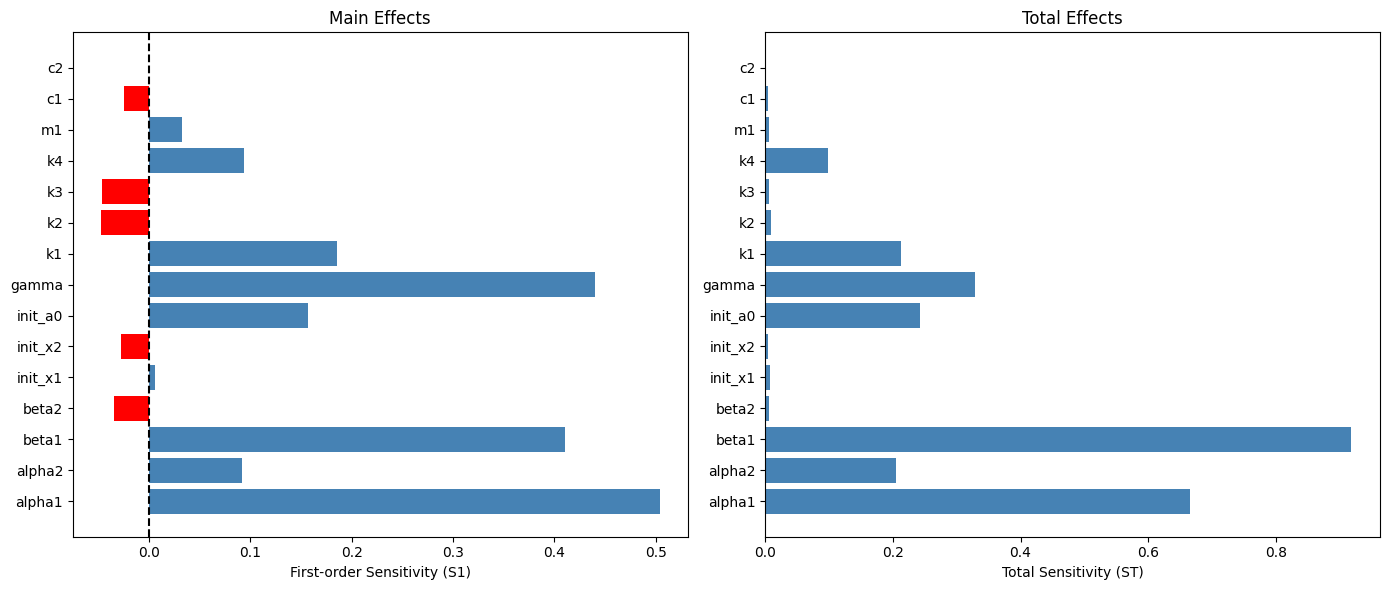

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# S1 plot
colors = ['red' if x < 0 else 'steelblue' for x in results_df['S1']]
axes[0].barh(results_df['Parameter'], results_df['S1'], color=colors)
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_xlabel('First-order Sensitivity (S1)')
axes[0].set_title('Main Effects')

# ST plot
axes[1].barh(results_df['Parameter'], results_df['ST'], color='steelblue')
axes[1].set_xlabel('Total Sensitivity (ST)')
axes[1].set_title('Total Effects')

plt.tight_layout()
plt.show()

In [27]:
total = len(result_weeks)
success = sum(1 for w in result_weeks if w >= 239)
partial = sum(1 for w in result_weeks if 95 <= w < 239) # 2 years
failure = sum(1 for w in result_weeks if w < 95)

print(f"Total parameter sets: {total}")
print(f"Success (240 weeks): {success} ({success/total*100:.1f}%)")
print(f"Partial success (96-239 weeks): {partial} ({partial/total*100:.1f}%)")
print(f"Early failure (<96 weeks): {failure} ({failure/total*100:.1f}%)")
print(f"Mean weeks: {np.mean(result_weeks):.1f} ± {np.std(result_weeks):.1f}")
print(f"Median weeks: {np.median(result_weeks):.1f}")

Total parameter sets: 256
Success (240 weeks): 111 (43.4%)
Partial success (96-239 weeks): 6 (2.3%)
Early failure (<96 weeks): 139 (54.3%)
Mean weeks: 122.4 ± 105.0
Median weeks: 62.0


In [28]:
# link the resulting weeks to the 256 sets of param_values
results_df = pd.DataFrame(param_values, columns=problem['names'])
results_df['best_weeks'] = result_weeks
results_df['success'] = results_df['best_weeks'] >= 239

success_params = results_df[results_df['success']].mean()
failure_params = results_df[~results_df['success']].mean()

comparison = pd.DataFrame({
    'Success_Group': success_params,
    'Failure_Group': failure_params,
    'Difference': success_params - failure_params
})
print(comparison)

            Success_Group  Failure_Group  Difference
alpha1           0.017013       0.030585   -0.013572
alpha2           0.028284       0.024163    0.004121
beta1            0.010909       0.006528    0.004381
beta2            0.018207       0.018876   -0.000669
init_x1         13.245355      15.101832   -1.856477
init_x2          0.116427       0.095700    0.020727
init_a0         25.831926      30.707974   -4.876048
gamma            0.088682       0.079974    0.008708
k1               0.488387       0.329580    0.158807
k2               2.188345       1.690302    0.498043
k3               7.145270       8.654310   -1.509040
k4               0.476140       0.476886   -0.000746
m1               0.000048       0.000051   -0.000003
c1               0.980152       1.015194   -0.035042
c2               0.980152       1.097953   -0.117801
best_weeks     239.000000      33.062069  205.937931
success          1.000000       0.000000    1.000000


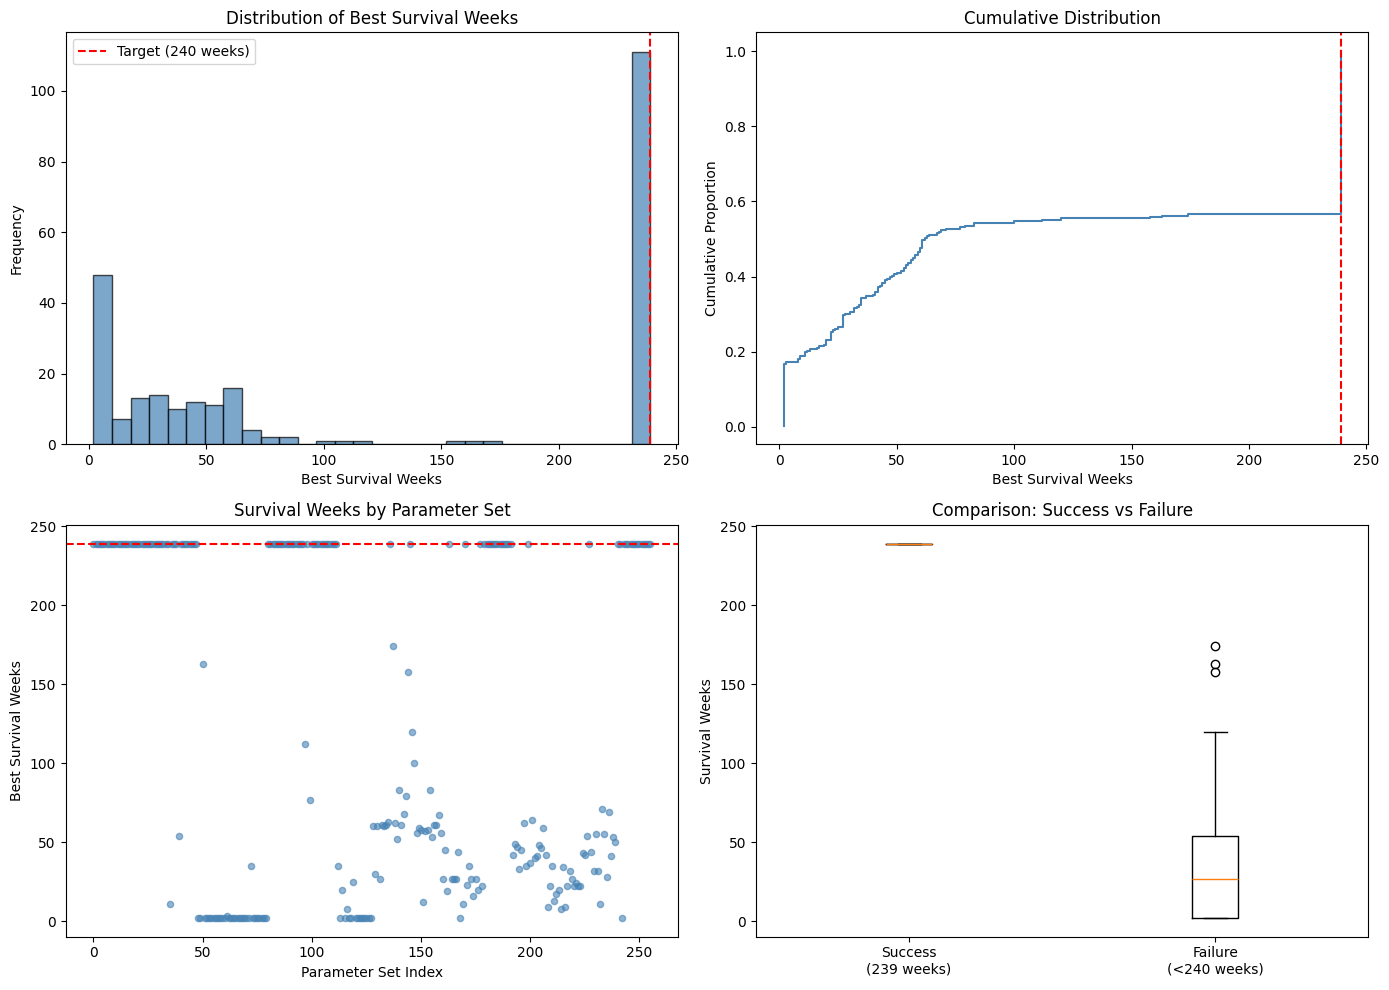

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax1 = axes[0, 0]
ax1.hist(result_weeks, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=239, color='red', linestyle='--', label='Target (240 weeks)')
ax1.set_xlabel('Best Survival Weeks')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Best Survival Weeks')
ax1.legend()

ax2 = axes[0, 1]
sorted_weeks = np.sort(result_weeks)
cumulative = np.arange(1, len(sorted_weeks)+1) / len(sorted_weeks)
ax2.step(sorted_weeks, cumulative, where='post', color='steelblue')
ax2.axvline(x=239, color='red', linestyle='--')
ax2.set_xlabel('Best Survival Weeks')
ax2.set_ylabel('Cumulative Proportion')
ax2.set_title('Cumulative Distribution')

ax3 = axes[1, 0]
ax3.scatter(range(len(result_weeks)), result_weeks, alpha=0.6, s=20, c='steelblue')
ax3.axhline(y=239, color='red', linestyle='--')
ax3.set_xlabel('Parameter Set Index')
ax3.set_ylabel('Best Survival Weeks')
ax3.set_title('Survival Weeks by Parameter Set')

ax4 = axes[1, 1]
success_weeks = [w for w in result_weeks if w >= 239]
failure_weeks = [w for w in result_weeks if w < 239]
bp = ax4.boxplot([success_weeks, failure_weeks], labels=['Success\n(239 weeks)', 'Failure\n(<240 weeks)'])
ax4.set_ylabel('Survival Weeks')
ax4.set_title('Comparison: Success vs Failure')

plt.tight_layout()
plt.savefig('survival_analysis.png', dpi=150)
plt.show()

In [30]:
from scipy.stats import ttest_ind

print("\n=== Parameter differences between success and failure groups ===")
for param in problem['names']:
    success_vals = results_df[results_df['success']][param]
    failure_vals = results_df[~results_df['success']][param]
    
    t_stat, p_value = ttest_ind(success_vals, failure_vals)
    
    print(f"{param:12s}: Success mean = {success_vals.mean():8.4f}, "
          f"Failure mean = {failure_vals.mean():8.4f}, "
          f"p = {p_value:.4f}")


=== Parameter differences between success and failure groups ===
alpha1      : Success mean =   0.0170, Failure mean =   0.0306, p = 0.0000
alpha2      : Success mean =   0.0283, Failure mean =   0.0242, p = 0.0035
beta1       : Success mean =   0.0109, Failure mean =   0.0065, p = 0.0000
beta2       : Success mean =   0.0182, Failure mean =   0.0189, p = 0.5286
init_x1     : Success mean =  13.2454, Failure mean =  15.1018, p = 0.0223
init_x2     : Success mean =   0.1164, Failure mean =   0.0957, p = 0.0001
init_a0     : Success mean =  25.8319, Failure mean =  30.7080, p = 0.0026
gamma       : Success mean =   0.0887, Failure mean =   0.0800, p = 0.0447
k1          : Success mean =   0.4884, Failure mean =   0.3296, p = 0.0000
k2          : Success mean =   2.1883, Failure mean =   1.6903, p = 0.0000
k3          : Success mean =   7.1453, Failure mean =   8.6543, p = 0.0005
k4          : Success mean =   0.4761, Failure mean =   0.4769, p = 0.9782
m1          : Success mean =   0.0

In [31]:
results_df = pd.DataFrame({
    'Parameter': problem['names'],
    'S1': SA_out['S1'],
    'S1_conf': SA_out['S1_conf'],
    'ST': SA_out['ST'],
    'ST_conf': SA_out['ST_conf']
})

print("="*60)
print("SENSITIVITY ANALYSIS RESULTS")
print("="*60)
print(results_df.round(4).to_string())

print("\n" + "="*60)
print("PARAMETERS RANKED BY IMPORTANCE (S1)")
print("="*60)
ranked = results_df.sort_values('S1', ascending=False)
for i, (_, row) in enumerate(ranked.iterrows(), 1):
    print(f"{i:2d}. {row['Parameter']:12s}: S1 = {row['S1']:8.4f}, ST = {row['ST']:8.4f}")

SENSITIVITY ANALYSIS RESULTS
   Parameter      S1  S1_conf      ST  ST_conf
0     alpha1  0.5037   0.5118  0.6653   0.6386
1     alpha2  0.0919   0.2989  0.2048   0.4262
2      beta1  0.4100   0.5765  0.9176   1.0035
3      beta2 -0.0341   0.0593  0.0053   0.0090
4    init_x1  0.0056   0.0841  0.0071   0.0104
5    init_x2 -0.0273   0.0562  0.0039   0.0080
6    init_a0  0.1573   0.4654  0.2428   0.4794
7      gamma  0.4397   0.5787  0.3290   0.4614
8         k1  0.1857   0.4177  0.2122   0.4335
9         k2 -0.0476   0.0802  0.0089   0.0159
10        k3 -0.0460   0.0675  0.0060   0.0088
11        k4  0.0941   0.2768  0.0976   0.1806
12        m1  0.0325   0.0665  0.0054   0.0112
13        c1 -0.0250   0.0587  0.0042   0.0080
14        c2 -0.0001   0.0002  0.0000   0.0000

PARAMETERS RANKED BY IMPORTANCE (S1)
 1. alpha1      : S1 =   0.5037, ST =   0.6653
 2. gamma       : S1 =   0.4397, ST =   0.3290
 3. beta1       : S1 =   0.4100, ST =   0.9176
 4. k1          : S1 =   0.1857, ST =   

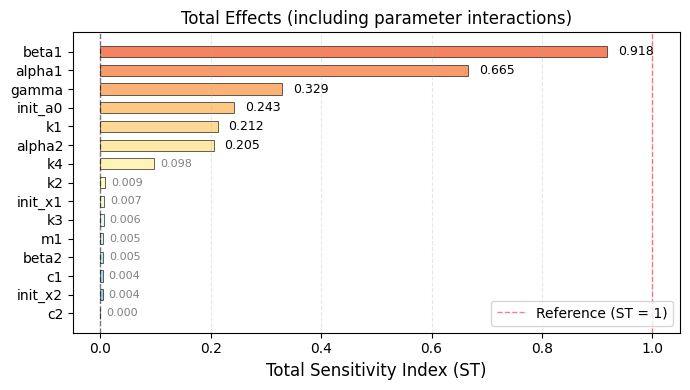

In [33]:
fig, ax = plt.subplots(figsize=(7,4))

sorted_idx = results_df['ST'].argsort()
params_sorted = results_df['Parameter'].iloc[sorted_idx]
st_sorted = results_df['ST'].iloc[sorted_idx]

colors = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(params_sorted)))
# colors = 'teal'
# colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(params_sorted)))

bars = ax.barh(params_sorted, st_sorted, 
               height=0.6,
               color=colors, 
               edgecolor='black', 
               linewidth=0.5,
               alpha=0.85)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Reference (ST = 1)')

for bar, st_val in zip(bars, st_sorted):
    if st_val > 0.1:
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{st_val:.3f}', va='center', fontsize=9)
    else:
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{st_val:.3f}', va='center', fontsize=8, color='gray')

ax.set_xlabel('Total Sensitivity Index (ST)', fontsize=12)
ax.set_title('Total Effects (including parameter interactions)', fontsize=12)

x_max = max(st_sorted.max(), 1.05)
ax.set_xlim(-0.05, x_max)

ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('tot_effects.pdf', bbox_inches='tight')
plt.show()

In [34]:
results_df['Parameter'] = results_df['Parameter'].replace('init_y0', 'gamma')
results_df.loc[results_df['Parameter'] == 'gamma', 'Parameter'] = 'init_y0'

print(results_df[results_df['Parameter'] == 'init_y0'])

  Parameter       S1   S1_conf        ST   ST_conf
7   init_y0  0.43974  0.578714  0.329012  0.461436
